In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from io import StringIO

In [4]:
# ── Data ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("DiffSeeds_results.csv")
case_df = pd.read_csv("Case_Data.csv")

In [5]:
# ── Style ─────────────────────────────────────────────────────────────────────
plt.style.use('ggplot')
SPLIT_COLORS = ["#E41A1C", "#377EB8", "#4DAF4A", "#FF7F00", "#984EA3"]

def style_box(bp, color):
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.55)
        patch.set_edgecolor(color)
        patch.set_linewidth(1.5)
    for med in bp['medians']:
        med.set_color("white")
        med.set_linewidth(2.2)
    for flier in bp['fliers']:
        flier.set(marker='o', markerfacecolor=color, markeredgecolor=color,
                  alpha=0.6, markersize=5)
    for w in bp['whiskers']:
        w.set_color(color)
        w.set_linewidth(1.2)
    for c in bp['caps']:
        c.set_color(color)
        c.set_linewidth(1.5)


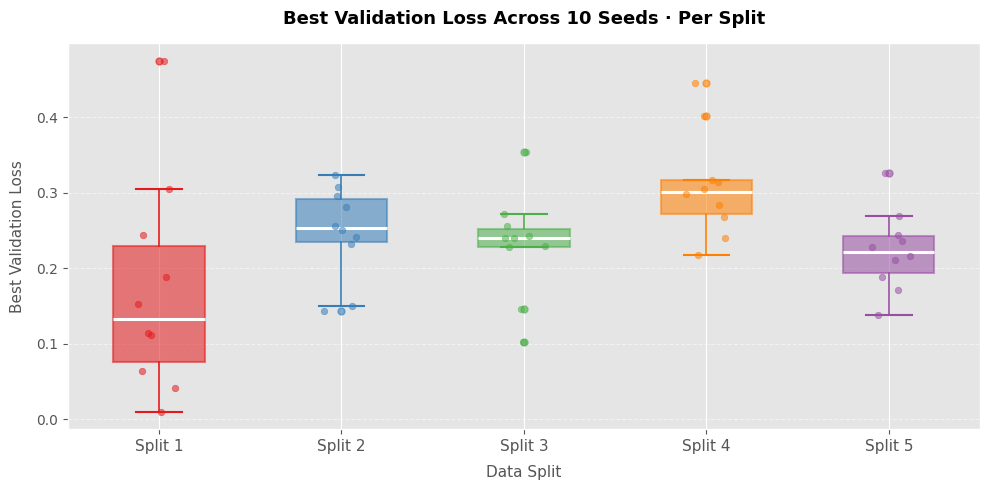

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Best Validation Loss per split
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))

for i, (split, col) in enumerate(zip(range(1, 6), SPLIT_COLORS), start=1):
    vals = df[df['split'] == split]['best val loss'].values
    bp = ax.boxplot(vals, positions=[i], widths=0.5, patch_artist=True, showfliers=True)
    style_box(bp, col)
    jitter = np.random.RandomState(42 + i).uniform(-0.12, 0.12, len(vals))
    ax.scatter([i + j for j in jitter], vals, color=col, alpha=0.55, s=22, zorder=5)

ax.set_xticks(range(1, 6))
ax.set_xticklabels([f"Split {s}" for s in range(1, 6)], fontsize=11)
ax.set_ylabel("Best Validation Loss", fontsize=11, labelpad=8)
ax.set_xlabel("Data Split", fontsize=11, labelpad=8)
ax.set_title("Best Validation Loss Across 10 Seeds · Per Split",
             fontsize=13, fontweight='bold', color="black", pad=14)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig("best_losses_by_split.png", dpi=150, bbox_inches='tight')
plt.show()


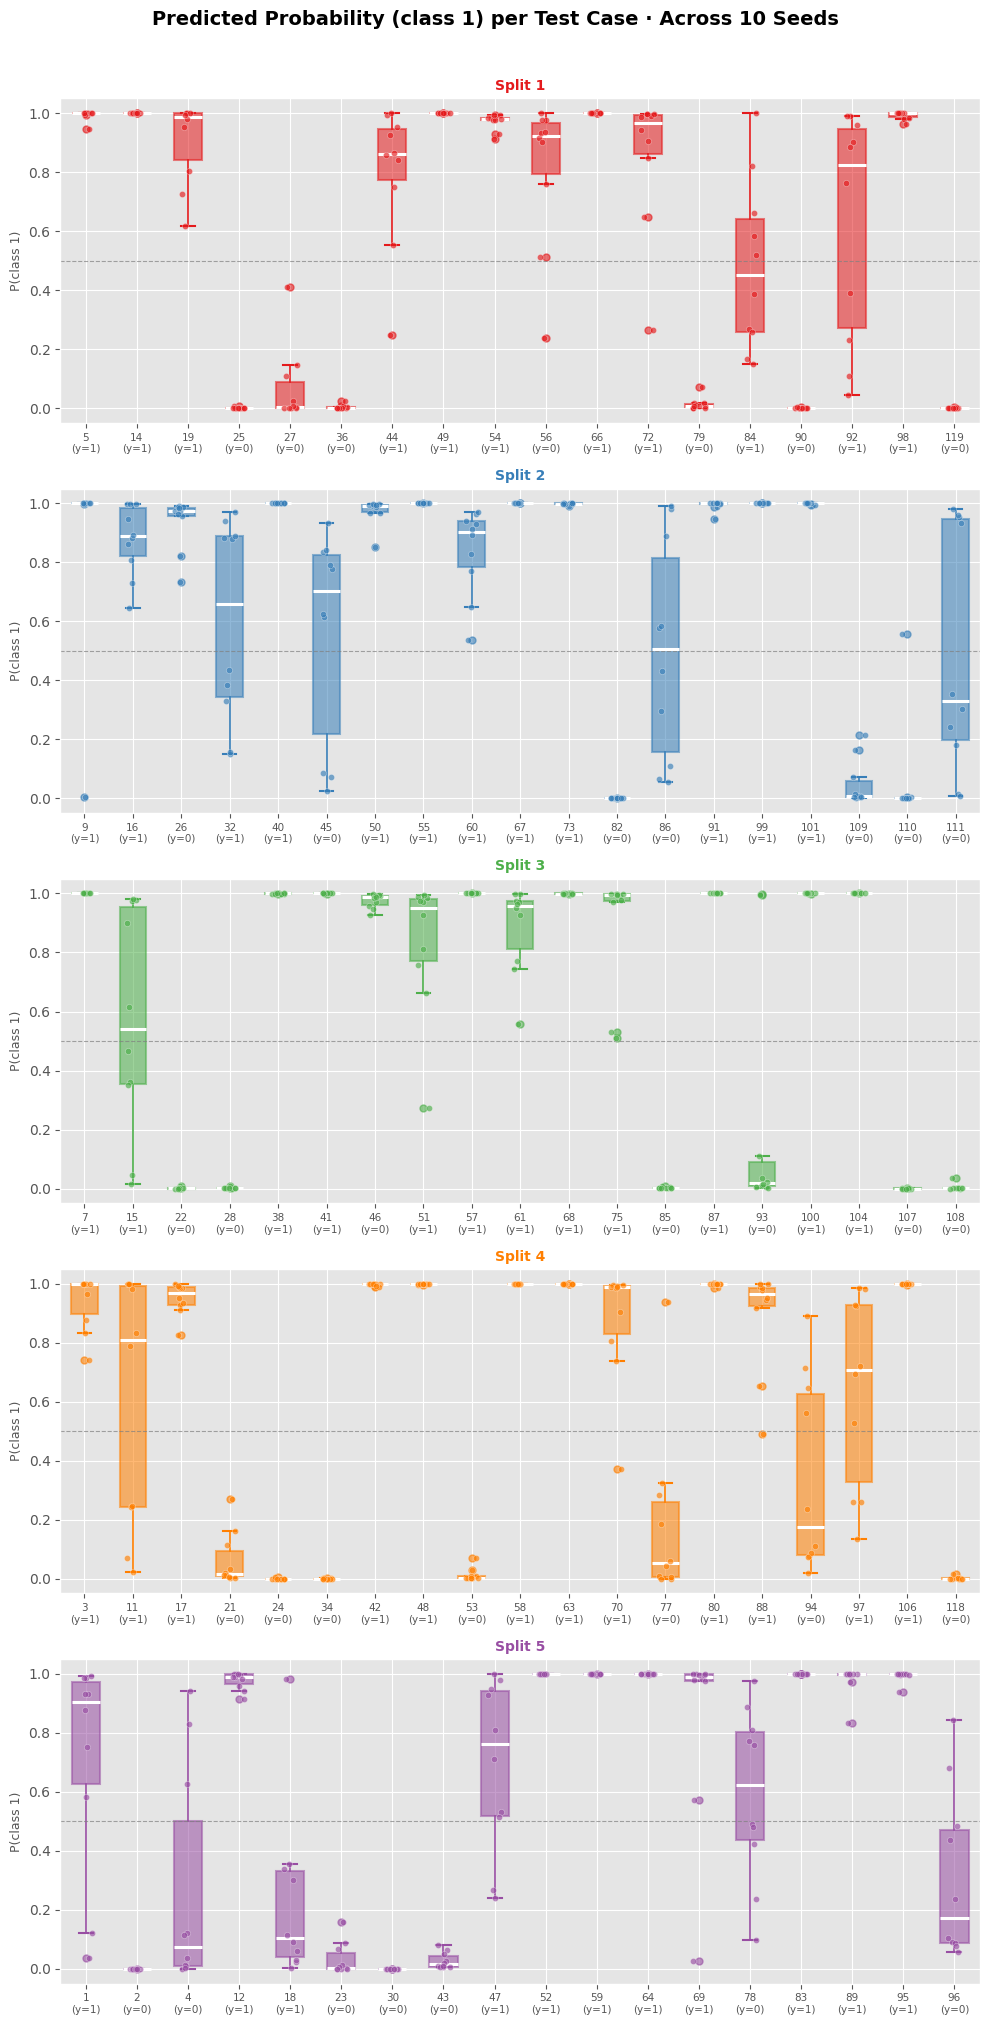

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Predicted Probability boxplots per case, faceted by split
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(5, 1, figsize=(10, 20), sharex=False)
fig.suptitle("Predicted Probability (class 1) per Test Case · Across 10 Seeds",
             fontsize=14, fontweight='bold', y=1.01)

for ax, split, col in zip(axes, range(1, 6), SPLIT_COLORS):
    sub   = case_df[case_df['split'] == split]
    cases = sorted(sub['case_id'].unique())
    data  = [sub[sub['case_id'] == c]['prob_class1'].values for c in cases]

    bp = ax.boxplot(data, positions=range(1, len(cases) + 1),
                    widths=0.55, patch_artist=True, showfliers=True)
    style_box(bp, col)

    # jitter overlay
    for i, (vals, pos) in enumerate(zip(data, range(1, len(cases) + 1))):
        jitter = np.random.RandomState(i).uniform(-0.13, 0.13, len(vals))
        ax.scatter([pos + j for j in jitter], vals,
                   color=col, alpha=0.65, s=20, zorder=5,
                   edgecolors='white', linewidths=0.3)

    # x-axis labels: case id + true label
    true_labels = [sub[sub['case_id'] == c]['true_label'].iloc[0] for c in cases]
    ax.set_xticks(range(1, len(cases) + 1))
    ax.set_xticklabels([f"{c}\n(y={t})" for c, t in zip(cases, true_labels)],
                       fontsize=7.5)
    ax.set_ylabel("P(class 1)", fontsize=9)
    ax.set_title(f"Split {split}", fontsize=10, fontweight='bold', color=col)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

fig.tight_layout()
fig.savefig("fig_predicted_probs.png", dpi=150, bbox_inches='tight')
plt.show()

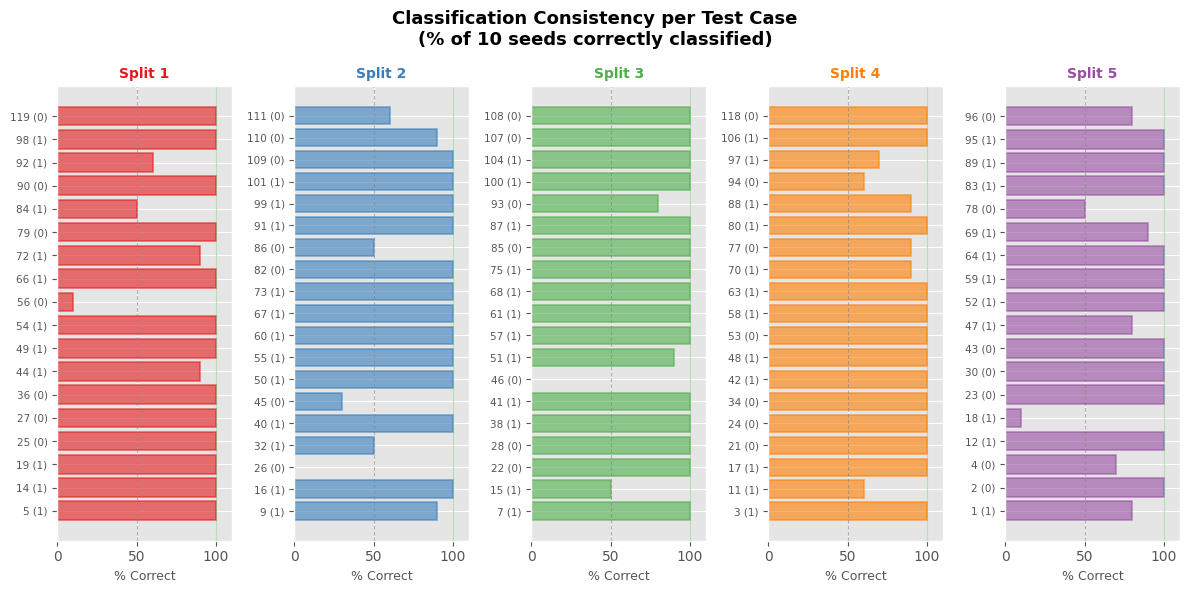

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Classification Consistency per case, faceted by split
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 5, figsize=(12, 6)) #, sharey=True)
fig.suptitle("Classification Consistency per Test Case\n"
             "(% of 10 seeds correctly classified)",
             fontsize=13, fontweight='bold')

for ax, split, col in zip(axes, range(1, 6), SPLIT_COLORS):
    sub   = case_df[case_df['split'] == split]
    cases = sorted(sub['case_id'].unique())

    consistency = []
    for c in cases:
        rows = sub[sub['case_id'] == c]
        pct  = (rows['correct'] == True).sum() / len(rows) * 100
        consistency.append(pct)

    true_labels = [sub[sub['case_id'] == c]['true_label'].iloc[0] for c in cases]
    ylabels     = [f"{c} ({t})" for c, t in zip(cases, true_labels)]

    bars = ax.barh(ylabels, consistency,
                   color=col, alpha=0.6, edgecolor=col, linewidth=1.2)

    ax.axvline(50,  color='grey',    linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axvline(100, color='#4DAF4A', linestyle='-',  linewidth=0.8, alpha=0.4)
    ax.set_xlim(0, 110)
    ax.set_xlabel("% Correct", fontsize=9)
    ax.set_title(f"Split {split}", fontsize=10, fontweight='bold', color=col)
    ax.tick_params(axis='y', labelsize=7.5)

fig.tight_layout()
fig.savefig("classification_consistency_per_test_case.png", dpi=150, bbox_inches='tight')
plt.show()

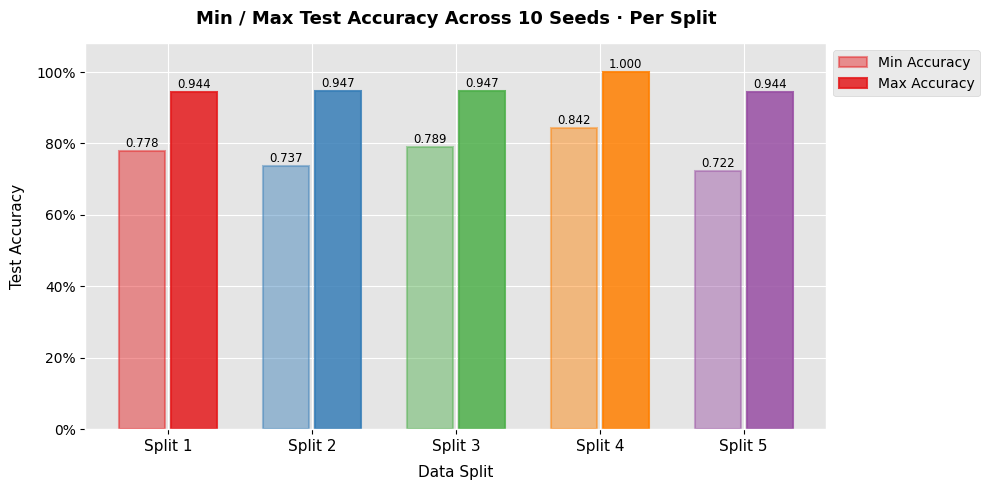

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Min / Max Accuracy Variability per split
# ══════════════════════════════════════════════════════════════════════════════
summary = df.groupby('split')['test acc'].agg(['min', 'max', 'mean']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(1, 6)

bars_min = ax.bar(x - 0.18, summary['min'], width=0.32,
                  color=SPLIT_COLORS, alpha=0.45,
                  edgecolor=SPLIT_COLORS, linewidth=1.5, label='Min Accuracy')
bars_max = ax.bar(x + 0.18, summary['max'], width=0.32,
                  color=SPLIT_COLORS, alpha=0.85,
                  edgecolor=SPLIT_COLORS, linewidth=1.5, label='Max Accuracy')

for bar in bars_min:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha='center', va='bottom',
            fontsize=8.5, color='black')

for bar in bars_max:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha='center', va='bottom',
            fontsize=8.5, color='black')

ax.set_xticks(x)
ax.set_xticklabels([f"Split {s}" for s in range(1, 6)], fontsize=11, color='black')

ax.set_ylabel("Test Accuracy", fontsize=11, labelpad=8, color='black')
ax.set_xlabel("Data Split", fontsize=11, labelpad=8, color='black')

ax.set_title("Min / Max Test Accuracy Across 10 Seeds · Per Split",
             fontsize=13, fontweight='bold', pad=14, color='black')

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0.0, 1.08)

ax.tick_params(axis='y', colors='black')
ax.tick_params(axis='x', colors='black')

legend = ax.legend(fontsize=10, bbox_to_anchor=(1, 1), loc='upper left')
for text in legend.get_texts():
    text.set_color('black')

fig.tight_layout()
fig.savefig("min_max_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()

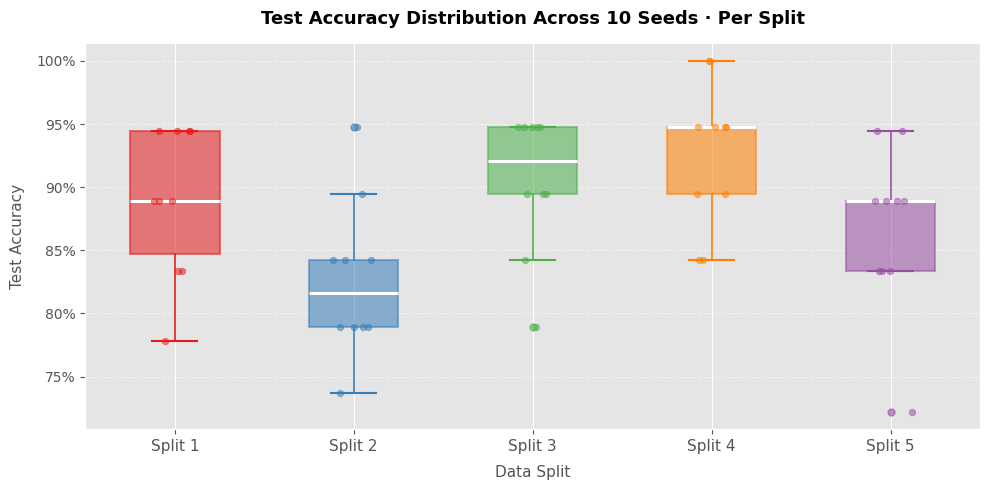

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Test Accuracy Distribution per split
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))

for i, (split, col) in enumerate(zip(range(1, 6), SPLIT_COLORS), start=1):
    vals = df[df['split'] == split]['test acc'].values
    bp = ax.boxplot(vals, positions=[i], widths=0.5, patch_artist=True, showfliers=True)
    style_box(bp, col)
    jitter = np.random.RandomState(99 + i).uniform(-0.12, 0.12, len(vals))
    ax.scatter([i + j for j in jitter], vals, color=col, alpha=0.55, s=22, zorder=5)

ax.set_xticks(range(1, 6))
ax.set_xticklabels([f"Split {s}" for s in range(1, 6)], fontsize=11)
ax.set_ylabel("Test Accuracy", fontsize=11, labelpad=8)
ax.set_xlabel("Data Split", fontsize=11, labelpad=8)
ax.set_title("Test Accuracy Distribution Across 10 Seeds · Per Split",
             fontsize=13, fontweight='bold', color="black", pad=14)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
fig.tight_layout()
fig.savefig("acc_dist.png", dpi=150, bbox_inches='tight')
plt.show()


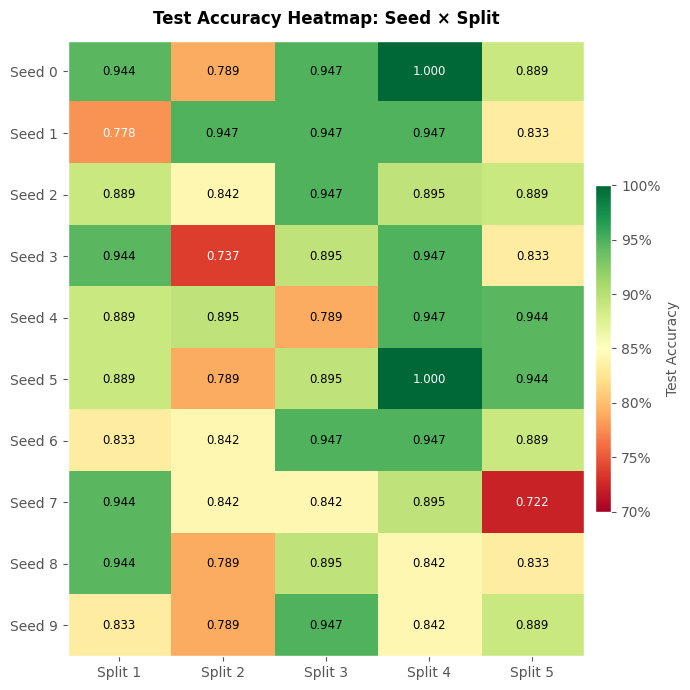

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Heatmap: Seed × Split (classification consistency proxy)
# ══════════════════════════════════════════════════════════════════════════════
pivot = df.pivot(index='seed', columns='split', values='test acc')

fig, ax = plt.subplots(figsize=(7, 7))
cmap = plt.cm.RdYlGn
im = ax.imshow(pivot.values, cmap=cmap, aspect='auto',
               vmin=0.7, vmax=1.0, interpolation='nearest')

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        text_color = 'black' if 0.78 < val < 0.95 else 'white'
        ax.text(j, i, f"{val:.3f}", ha='center', va='center',
                fontsize=8.5, color=text_color)

ax.set_xticks(range(5))
ax.set_xticklabels([f"Split {s}" for s in range(1, 6)], fontsize=10)
ax.set_yticks(range(10))
ax.set_yticklabels([f"Seed {s}" for s in range(10)], fontsize=10)
ax.set_title("Test Accuracy Heatmap: Seed × Split",
             fontsize=12, fontweight='bold', color="black", pad=12)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Test Accuracy", fontsize=10)
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.grid(False)
fig.tight_layout()

fig.savefig("acc_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CONSOLE REPORT
# ══════════════════════════════════════════════════════════════════════════════
print("\n=== ACCURACY VARIABILITY PER SPLIT ===")
print(f"{'Split':<8} {'Min':>8} {'Max':>8} {'Range':>8} {'Mean':>8}")
print("-" * 44)

for _, row in summary.iterrows():
    rng = row['max'] - row['min']
    print(f"{int(row['split']):<8} {row['min']:>8.4f} {row['max']:>8.4f} {rng:>8.4f} {row['mean']:>8.4f}")

print("\n=== CLASSIFICATION CONSISTENCY (% correct runs per split) ===")
print("Note: based on test accuracy as proxy (no per-case labels provided)")

# compute median per split
median_acc = df.groupby('split')['test acc'].transform('median')

consistency = (
    (df['test acc'] >= median_acc)
    .groupby(df['split'])
    .mean()
    .mul(100)
    .reset_index(name='pct_above_median')
)

print(consistency.to_string(index=False))

print("\n=== CASES WITH <100% CONSISTENCY ===")
print(f"{'Split':<8} {'Case':>6} {'True Label':>12} {'% Correct':>10}")
print("-" * 42)
for split in range(1, 6):
    sub = case_df[case_df['split'] == split]
    for c in sorted(sub['case_id'].unique()):
        rows = sub[sub['case_id'] == c]
        pct  = (rows['correct'] == True).sum() / len(rows) * 100
        if pct < 100:
            tl = rows['true_label'].iloc[0]
            print(f"{split:<8} {c:>6} {tl:>12} {pct:>9.0f}%")


=== ACCURACY VARIABILITY PER SPLIT ===
Split         Min      Max    Range     Mean
--------------------------------------------
1          0.7778   0.9444   0.1666   0.8889
2          0.7368   0.9474   0.2106   0.8263
3          0.7895   0.9474   0.1579   0.9053
4          0.8421   1.0000   0.1579   0.9263
5          0.7222   0.9444   0.2222   0.8667

=== CLASSIFICATION CONSISTENCY (% correct runs per split) ===
Note: based on test accuracy as proxy (no per-case labels provided)
 split  pct_above_median
     1              70.0
     2              50.0
     3              50.0
     4              60.0
     5              60.0

=== CASES WITH <100% CONSISTENCY ===
Split      Case   True Label  % Correct
------------------------------------------
1            44            1        90%
1            56            0        10%
1            72            1        90%
1            84            1        50%
1            92            1        60%
2             9            1        90%
2  